# OG statystyki

In [56]:
def print_og_network_stats():
    n = 3892
    e = 17262
    density_ba = 0.002280
    num_components_ba = 1
    avg_path_ba = 6.2759
    diameter_ba = 20
    deg_min, deg_max, deg_avg = 1, 126, 8.87

    print(f"--- WYNIKI DLA MODELU OG ---")
    print(f"n={n}, e={e}")
    print(f"Gęstość: {density_ba:.6f}")
    print(f"Liczba składowych: {num_components_ba}")
    print(f"Średnia długość ścieżki: {avg_path_ba:.4f}")
    print(f"Średnica: {diameter_ba}")
    print(f"Stopień min: {deg_min}, max: {deg_max}, średni: {deg_avg:.2f}")

def print_og_community_stats():
    num_communities = 44
    modularity = 0.8727
    max_size = 285
    min_size = 14
    avg_size = 88.45
    avg_internal_clustering = 0.4165

    print(f"--- ANALIZA SPOŁECZNOŚCI (LOUVAIN) - OG ---")
    print(f"Liczba grup: {num_communities}")
    print(f"Modułowość: {modularity:.4f}")
    print(f"Max rozmiar grupy: {max_size}")
    print(f"Min rozmiar grupy: {min_size}")
    print(f"Średni rozmiar grupy: {avg_size:.2f}")
    print(f"Wyspowany współczynnik grupowania: {avg_internal_clustering:.4f}")
    print("-" * 40)

# Rozruch

In [39]:
import networkx as nx

n = 3892
target_edges = 17262

#erdos renyi
p = target_edges / (n * (n - 1) / 2)
g_erd_ren = nx.erdos_renyi_graph(n, p)

# Barabasi-Albert
# m=4 daje koło 15.5k krawędzi m=5 19.4k
m = 4
g_ba = nx.barabasi_albert_graph(n, m)


print(f"OG: n=3892, e=17262")
print(f"erdos renyi: n={g_erd_ren.number_of_nodes()}, e={g_erd_ren.number_of_edges()}")
print(f"BA:      n={g_ba.number_of_nodes()}, e={g_ba.number_of_edges()}")

OG: n=3892, e=17262
erdos renyi: n=3892, e=17194
BA:      n=3892, e=15552


### fcja statystykująca

In [53]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def analyze_graph(G, name="OG"):
    n = G.number_of_nodes()
    e = G.number_of_edges()
    density_ba = nx.density(G)
    num_components_ba = nx.number_connected_components(G)

    if nx.is_connected(G):
        diameter_ba = nx.diameter(G)
        avg_path_ba = nx.average_shortest_path_length(G)
    else:
        diameter_ba = "Niespójny"
        avg_path_ba = "Niespójny"

    degrees = [d for n, d in G.degree()]
    deg_min = min(degrees) if degrees else 0
    deg_max = max(degrees) if degrees else 0
    deg_avg = sum(degrees) / n if n > 0 else 0

    print(f"--- WYNIKI DLA MODELU {name} ---")
    print(f"n={n}, e={e}")
    print(f"Gęstość: {density_ba:.6f}")
    print(f"Liczba składowych: {num_components_ba}")

    if isinstance(avg_path_ba, (float, int)):
        print(f"Średnia długość ścieżki: {avg_path_ba:.4f}")
    else:
        print(f"Średnia długość ścieżki: {avg_path_ba}")

    print(f"Średnica: {diameter_ba}")
    print(f"Stopień min: {deg_min}, max: {deg_max}, średni: {deg_avg:.2f}")
    print("-" * 30)


    print_og_network_stats()

    deg_centrality = list(nx.degree_centrality(G).values())
    close_centrality = list(nx.closeness_centrality(G).values())
    bet_centrality = list(nx.betweenness_centrality(G).values())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Analiza centralności - {name}', fontsize=16)

    titles = ['Degree Centrality', 'Closeness Centrality', 'Betweenness Centrality']
    data = [deg_centrality, close_centrality, bet_centrality]
    colors = ['orange', 'skyblue', 'lightgreen']

    for ax, d, title, color in zip(axes, data, titles, colors):
        ax.hist(d, bins=50, color=color, edgecolor='black', alpha=0.7)
        ax.set_title(title)
        ax.set_yscale('log')
        ax.set_xlabel('Wartość')
        ax.set_ylabel('Liczba wierzchołków (log)')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    display(Image(filename='OG_nodes.png'))



# BA

--- WYNIKI DLA MODELU Barabasi-Albert ---
n=3892, e=15552
Gęstość: 0.002054
Liczba składowych: 1
Średnia długość ścieżki: 3.5996
Średnica: 6
Stopień min: 4, max: 196, średni: 7.99
------------------------------
--- WYNIKI DLA MODELU OG ---
n=3892, e=17262
Gęstość: 0.002280
Liczba składowych: 1
Średnia długość ścieżki: 6.2759
Średnica: 20
Stopień min: 1, max: 126, średni: 8.87


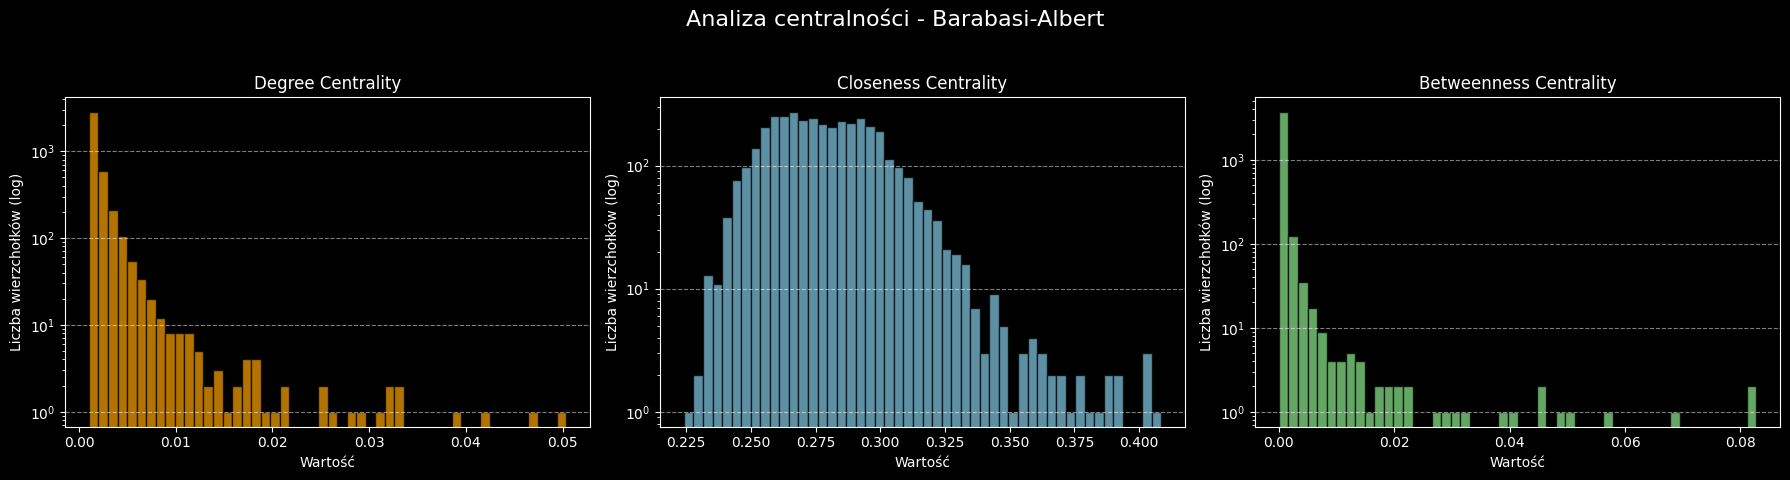

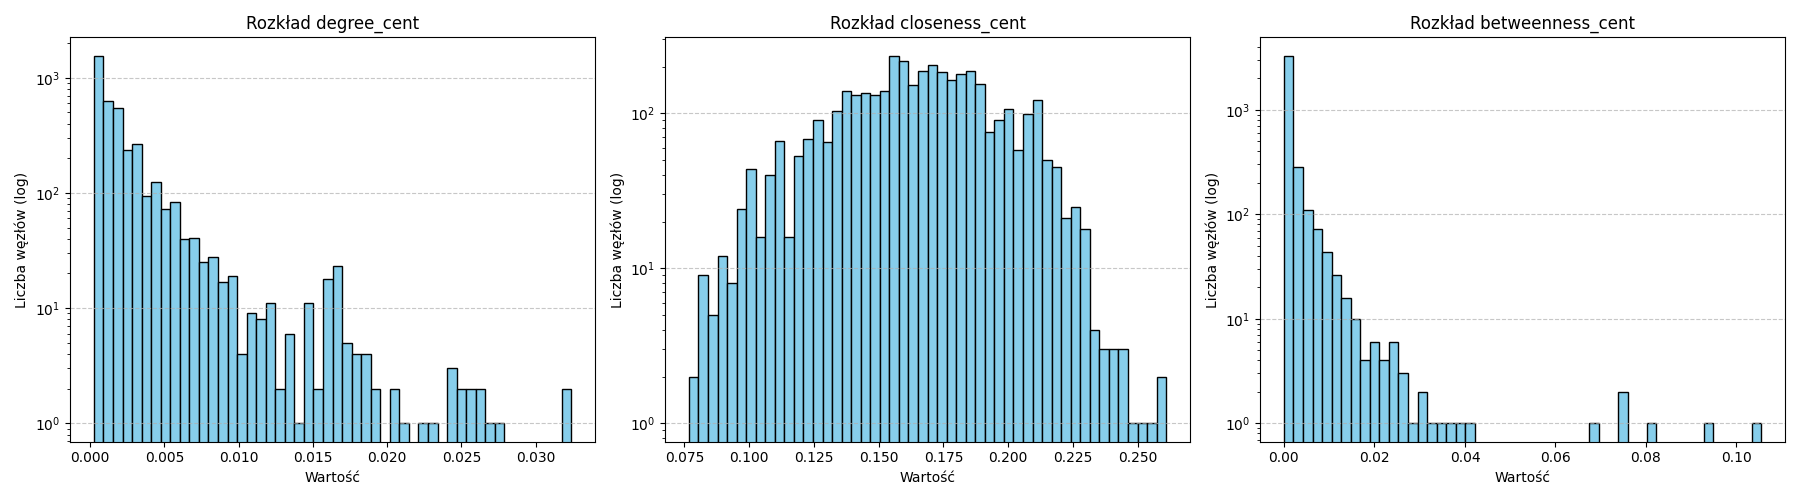

In [54]:
analyze_graph(g_ba, "Barabasi-Albert")

# ER

--- WYNIKI DLA MODELU Erdos renyi ---
n=3892, e=17194
Gęstość: 0.002271
Liczba składowych: 4
Średnia długość ścieżki: Niespójny
Średnica: Niespójny
Stopień min: 0, max: 21, średni: 8.84
------------------------------
--- WYNIKI DLA MODELU OG ---
n=3892, e=17262
Gęstość: 0.002280
Liczba składowych: 1
Średnia długość ścieżki: 6.2759
Średnica: 20
Stopień min: 1, max: 126, średni: 8.87


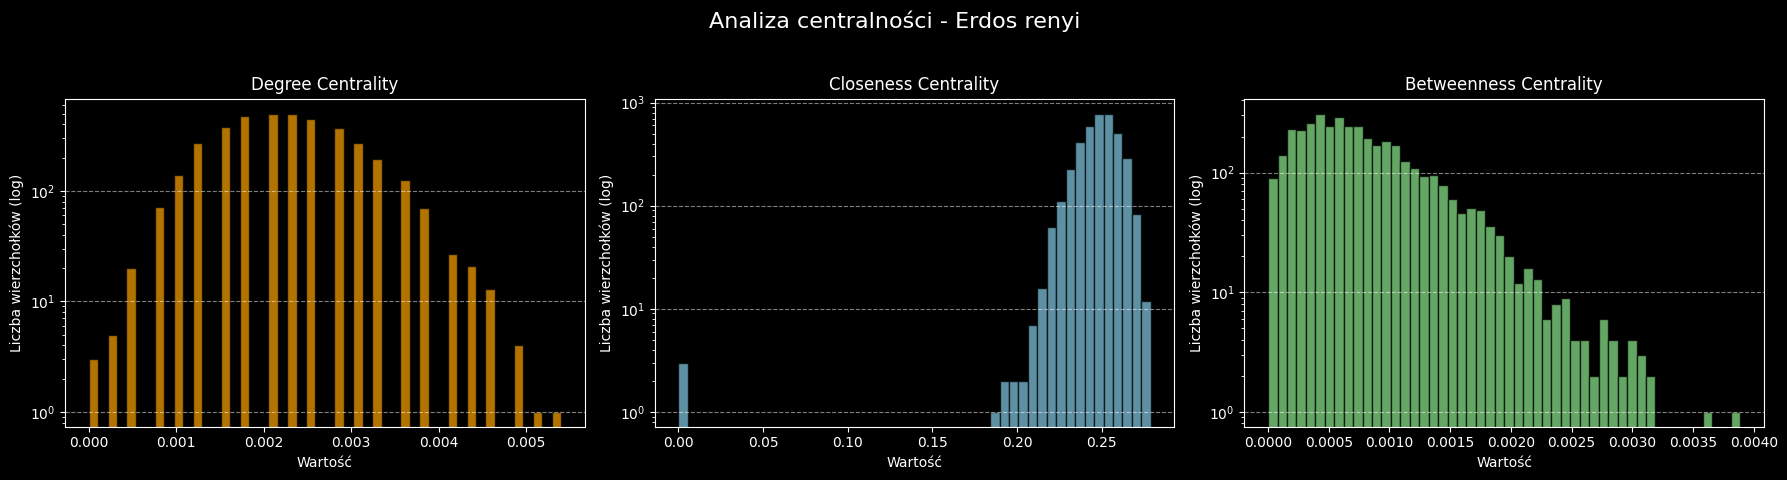

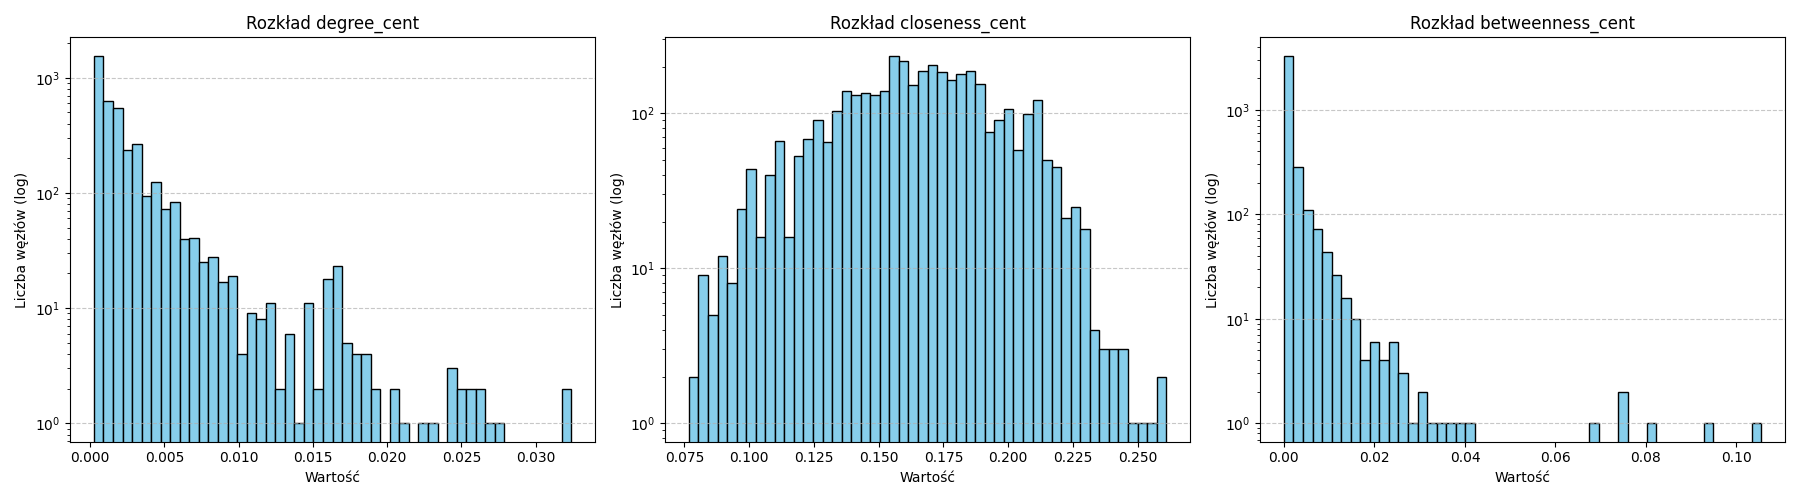

In [55]:
analyze_graph(g_erd_ren, "Erdos renyi")

# Grupowanie

In [65]:
def analyze_communities_louvain(G, name="OG"):
    import networkx as nx
    communities = nx.community.louvain_communities(G, seed=67)
    num_communities = len(communities)

    modularity = nx.community.modularity(G, communities)
    sizes = sorted([len(c) for c in communities], reverse=True)

    internal_clustering = []
    for comm in communities:
        if len(comm) >= 3:
            subgraph = G.subgraph(comm)
            internal_clustering.append(nx.average_clustering(subgraph))

    avg_internal_clustering = sum(internal_clustering) / len(internal_clustering) if internal_clustering else 0

    print(f"--- ANALIZA SPOŁECZNOŚCI (LOUVAIN) - {name} ---")
    print(f"Liczba grup: {num_communities}")
    print(f"Modułowość: {modularity:.4f}")
    print(f"Max rozmiar grupy: {sizes[0]}")
    print(f"Min rozmiar grupy: {sizes[-1]}")
    print(f"Średni rozmiar grupy: {sum(sizes) / len(sizes):.2f}")
    print(f"Wyspowany współczynnik grupowania: {avg_internal_clustering:.4f}")
    print("-" * 40)

    print_og_community_stats()

    plt.figure(figsize=(10, 4))
    plt.hist(sizes, bins=30, color='skyblue', edgecolor='black', alpha=0.8)
    plt.title(f'Rozkład wielkości społeczności - {name}')
    plt.xlabel('Rozmiar społeczności')
    plt.ylabel('Liczba społeczności')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()
    display(Image(filename='OG_groups_louvain.png'))
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

    node_to_comm = {node: i for i, comm in enumerate(communities) for node in comm}
    colors = [node_to_comm.get(n, 0) for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_size=30, node_color=colors, cmap=plt.cm.tab20)
    nx.draw_networkx_edges(G, pos, alpha=0.05)

    plt.title(f"Wizualizacja społeczności (Spring Layout) - {name}")
    plt.axis('off')
    plt.show()
    display(Image(filename='OG_louvain_spring.png'))

    return

### BA

--- ANALIZA SPOŁECZNOŚCI (LOUVAIN) - Barabasi-Albert ---
Liczba grup: 18
Modułowość: 0.3175
Max rozmiar grupy: 483
Min rozmiar grupy: 39
Średni rozmiar grupy: 216.22
Wyspowany współczynnik grupowania: 0.0233
----------------------------------------
--- ANALIZA SPOŁECZNOŚCI (LOUVAIN) - OG ---
Liczba grup: 44
Modułowość: 0.8727
Max rozmiar grupy: 285
Min rozmiar grupy: 14
Średni rozmiar grupy: 88.45
Wyspowany współczynnik grupowania: 0.4165
----------------------------------------


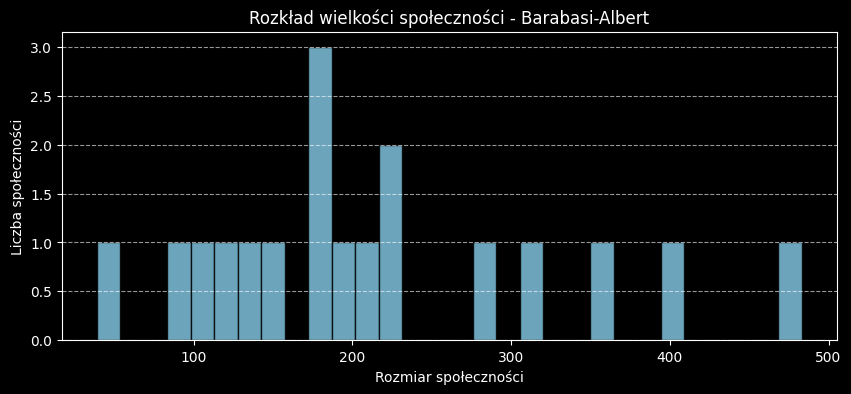

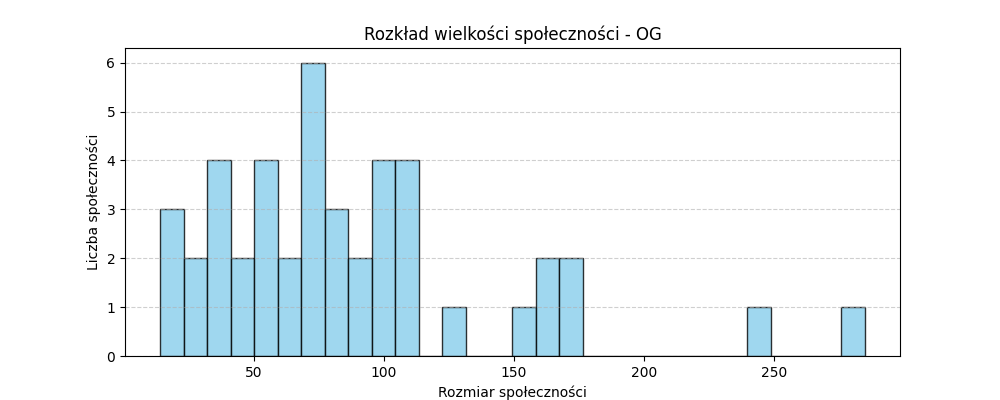

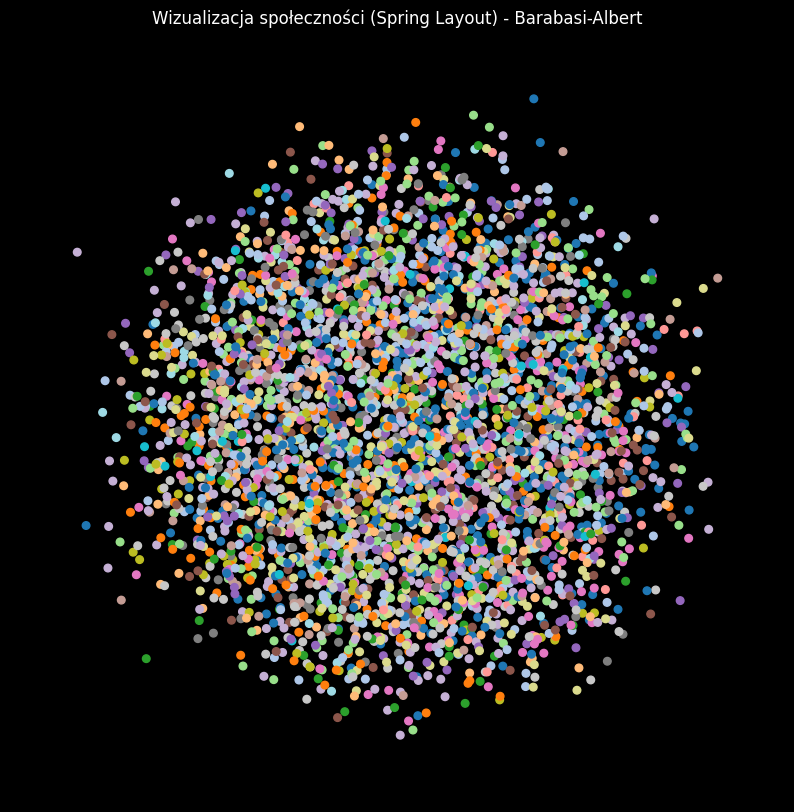

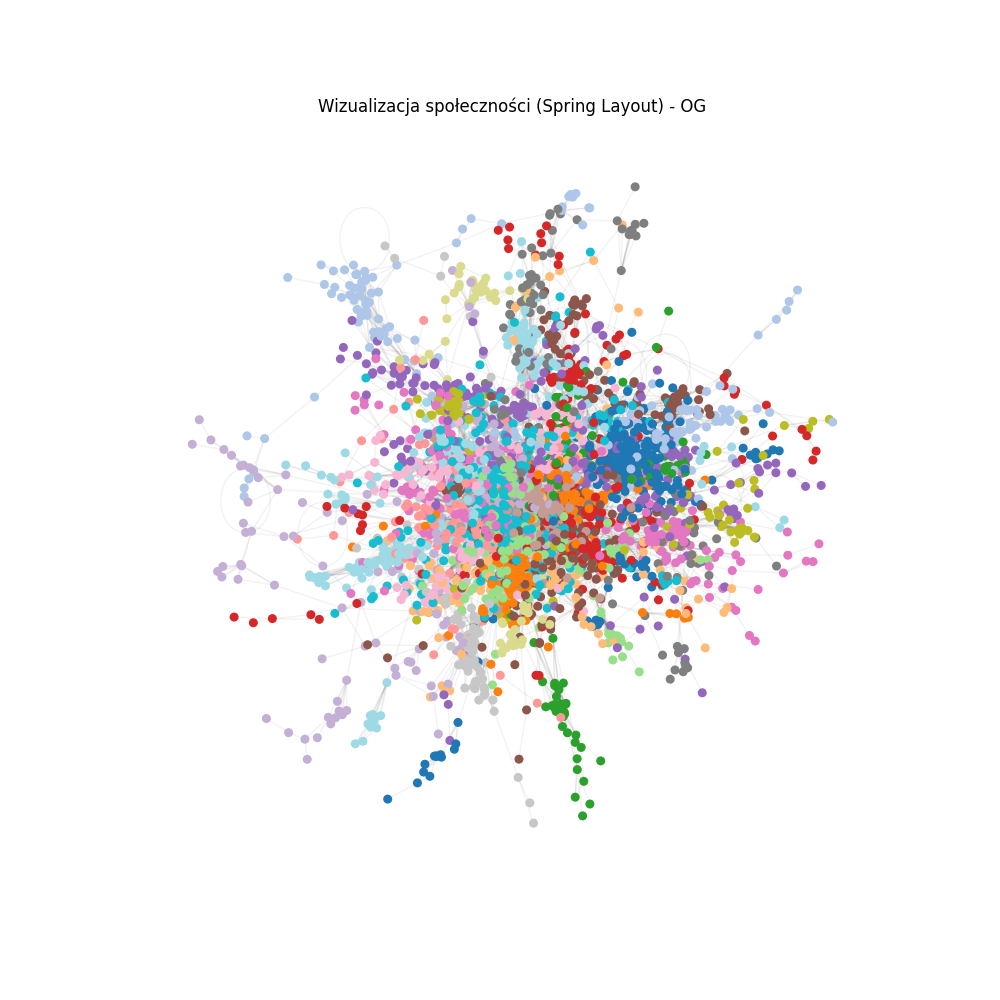

In [66]:
analyze_communities_louvain(g_ba, "Barabasi-Albert")

### ER

--- ANALIZA SPOŁECZNOŚCI (LOUVAIN) - Erdos renyi ---
Liczba grup: 25
Modułowość: 0.2919
Max rozmiar grupy: 648
Min rozmiar grupy: 1
Średni rozmiar grupy: 155.68
Wyspowany współczynnik grupowania: 0.0155
----------------------------------------
--- ANALIZA SPOŁECZNOŚCI (LOUVAIN) - OG ---
Liczba grup: 44
Modułowość: 0.8727
Max rozmiar grupy: 285
Min rozmiar grupy: 14
Średni rozmiar grupy: 88.45
Wyspowany współczynnik grupowania: 0.4165
----------------------------------------


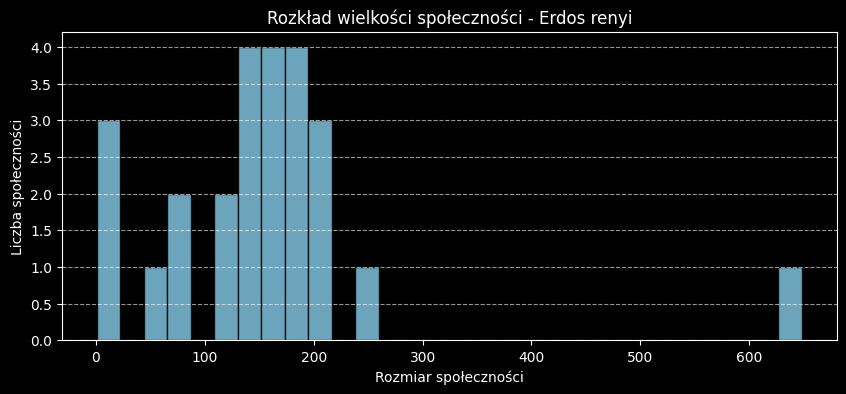

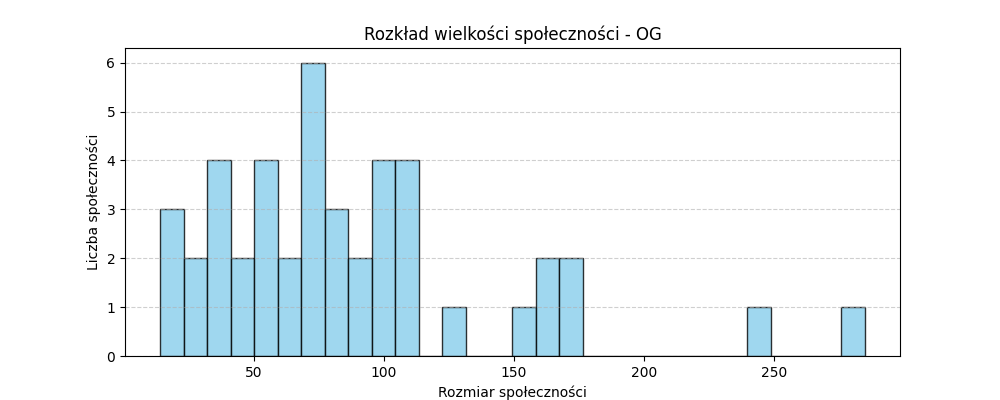

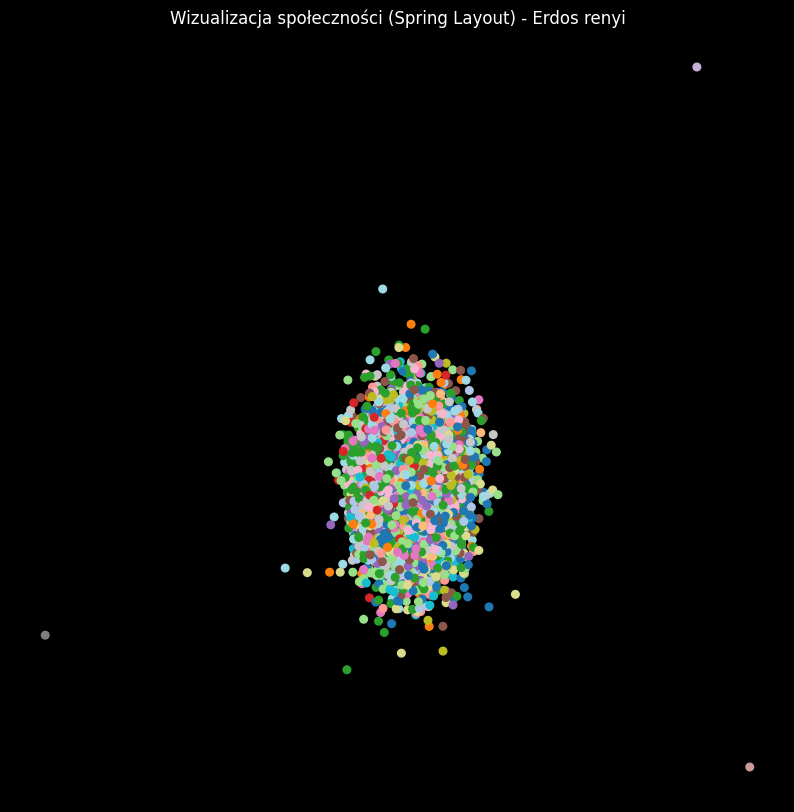

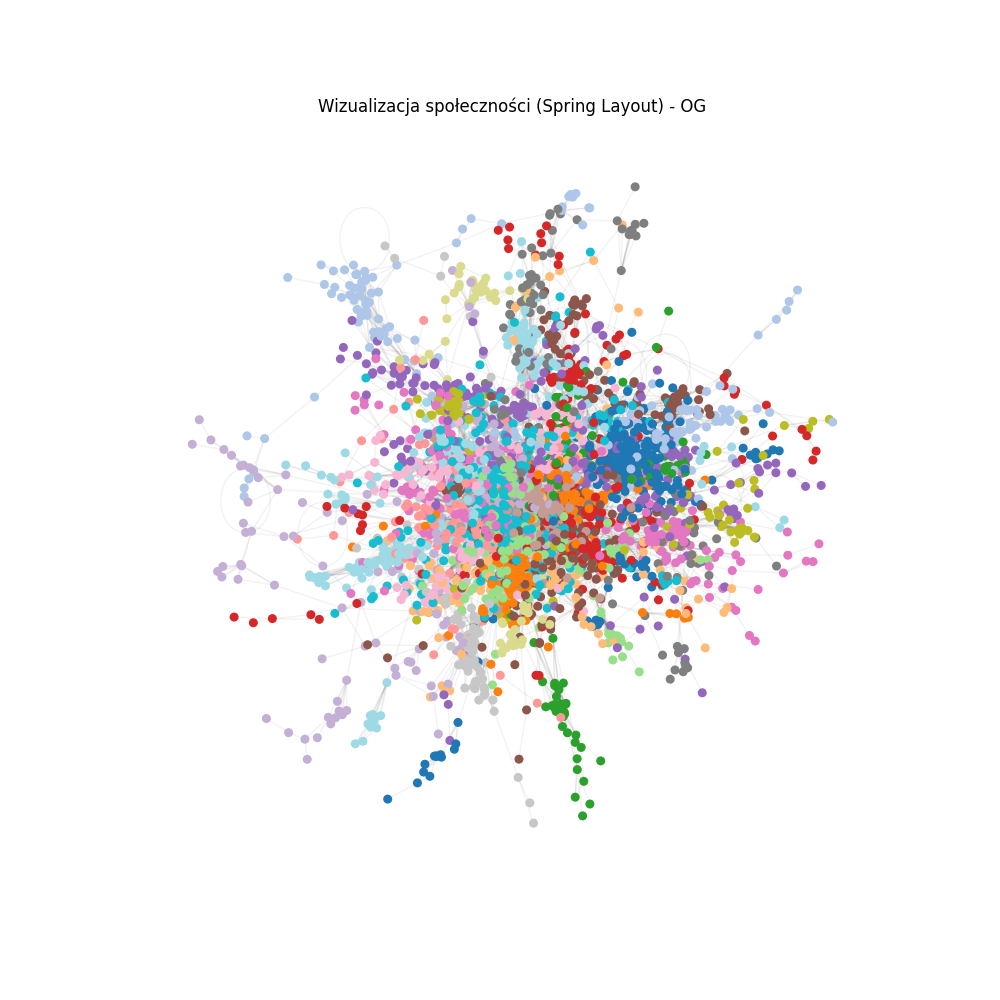

In [67]:
analyze_communities_louvain(g_erd_ren, "Erdos renyi")

# Wizualizacja właściwości